In [ ]:
import kagglehub
mariaherrerot_aptos2019_path = kagglehub.dataset_download('mariaherrerot/aptos2019')

print('Data source import complete.')


Using Colab cache for faster access to the 'aptos2019' dataset.
Data source import complete.


In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
import os
print(os.listdir("/kaggle/input"))

print("Dataset root:", mariaherrerot_aptos2019_path)
print()

for root, dirs, files in os.walk(mariaherrerot_aptos2019_path):
    depth = root.replace(mariaherrerot_aptos2019_path, "").count(os.sep)
    if depth <= 2:  # don't dump thousands of image filenames
        print("  " * depth + os.path.basename(root) + "/")
        for f in files[:3]:
            print("  " * (depth + 1) + f)
        if len(files) > 3:
            print("  " * (depth + 1) + f"... ({len(files)} files total)")

['aptos2019']
Dataset root: /kaggle/input/aptos2019

aptos2019/
  valid.csv
  test.csv
  train_1.csv
  val_images/
    val_images/
      17f6c7072f61.png
      0243404e8a00.png
      0083ee8054ee.png
      ... (366 files total)
  train_images/
    train_images/
      6dcde47060f9.png
      b49b2fac2514.png
      af6166d57f13.png
      ... (2930 files total)
  test_images/
    test_images/
      ef476be214d4.png
      ec363f48867b.png
      f481f76a6b75.png
      ... (366 files total)


In [ ]:
import pandas as pd

train_df = pd.read_csv(f"{mariaherrerot_aptos2019_path}/train_1.csv")
valid_df = pd.read_csv(f"{mariaherrerot_aptos2019_path}/valid.csv")

print("TRAIN columns:", list(train_df.columns))
print(train_df.head(3))
print()
print("VALID columns:", list(valid_df.columns))
print(valid_df.head(3))

TRAIN columns: ['id_code', 'diagnosis']
        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4

VALID columns: ['id_code', 'diagnosis']
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,594 (3.15 MB)

 Trainable params: 826,594 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.8297 - loss: 0.3601 - val_accuracy: 0.9344 - val_loss: 0.1793
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.9150 - loss: 0.2342 - val_accuracy: 0.9426 - val_loss: 0.1627
Epoch 3/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9242 - loss: 0.2140 - val_accuracy: 0.9454 - val_loss: 0.1502
Epoch 4/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9355 - loss: 0.1941 - val_accuracy: 0.9536 - val_loss: 0.1263
Epoch 5/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9324 - loss: 0.1933 - val_accuracy: 0.9481 - val_loss: 0.1379
Epoch 6/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.9382 - loss: 0.1814 - val_accuracy: 0.9481 - val_loss: 0.1588
Epoch 7/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9362 - loss: 0.1797 - val_accuracy: 0.9426 - val_loss: 0.1307
Epoch 8/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9382 - loss: 0.1815 - val_accuracy: 0.9508 - v

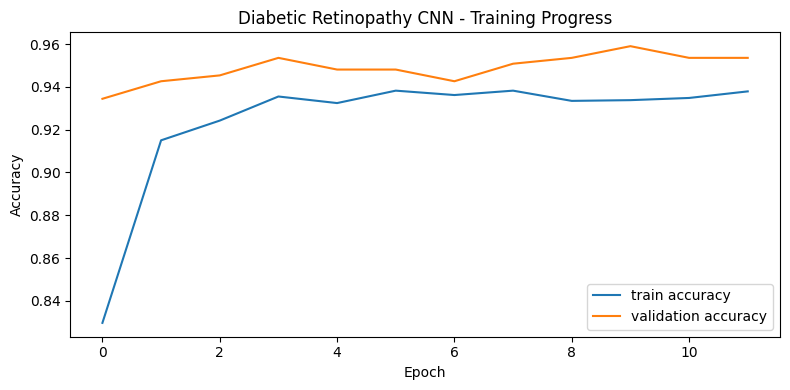

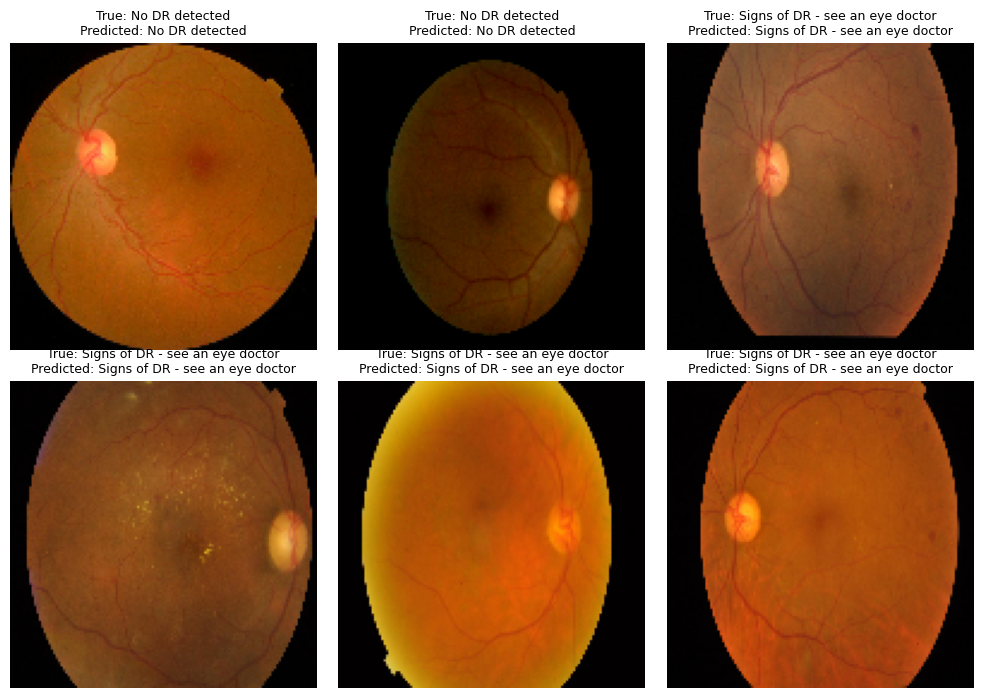

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

DATA_DIR = mariaherrerot_aptos2019_path

TRAIN_CSV = os.path.join(DATA_DIR, "train_1.csv")
VALID_CSV = os.path.join(DATA_DIR, "valid.csv")
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images", "train_images")
VALID_IMG_DIR = os.path.join(DATA_DIR, "val_images", "val_images")

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 12

BINARY_MODE = True

def load_labels(csv_path, img_dir):
    d = pd.read_csv(csv_path)  # columns: id_code, diagnosis
    d["filepath"] = d["id_code"].apply(
        lambda x: os.path.join(img_dir, f"{x}.png")
    )
    return d

train_df = load_labels(TRAIN_CSV, TRAIN_IMG_DIR)
val_df = load_labels(VALID_CSV, VALID_IMG_DIR)

if BINARY_MODE:
    for d in (train_df, val_df):
        d["label"] = (d["diagnosis"] > 0).astype(int)  # 0 = no DR, 1 = DR
    num_classes = 2
    class_names = ["No DR detected", "Signs of DR - see an eye doctor"]
else:
    for d in (train_df, val_df):
        d["label"] = d["diagnosis"]
    num_classes = 5
    class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0  # normalize to 0-1
    return img

def make_dataset(dataframe, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        return load_image(path), label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000)
        ds = ds.map(
            lambda x, y: (tf.image.random_flip_left_right(x), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

val_loss, val_acc = model.evaluate(val_ds)
print(f"\nFinal validation accuracy: {val_acc*100:.1f}%")

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Diabetic Retinopathy CNN - Training Progress")
plt.legend()
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()

model.save("dr_screening_cnn.keras")
sample = val_df.sample(6, random_state=1)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = load_image(row["filepath"])
    pred = model.predict(tf.expand_dims(img, 0), verbose=0)
    pred_class = np.argmax(pred)
    ax.imshow(img)
    ax.set_title(
        f"True: {class_names[row['label']]}\n"
        f"Predicted: {class_names[pred_class]}",
        fontsize=9,
    )
    ax.axis("off")
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150)
plt.show()